## Document Classification: Ham or Spam

### Introduction

Documents such as emails can be either legitimate (ham) or malicious (spam). There are often trends in spam that can be used to find those emails. We often take things for granted until an email is incorrectly filtered. We will be analyzing a copy of the UCI Spambase Data Set and train a classification model through it.

### Full Dataset EDA

In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from scipy.sparse import hstack
from sklearn.naive_bayes import MultinomialNB

The data was saved ahead of time because of accessibility issues with the original hosted location.

In [3]:
# Load data
df = pd.read_csv('https://raw.githubusercontent.com/Megabuster/DATA620/refs/heads/main/HW10/sms_spam_data.csv')

display(df.head())

# (0 = ham, 1 = spam)
print(df['label'].value_counts())

,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


label
0    4827
1     747
Name: count, dtype: int64


The data has 2 columns: `sms` and `label`. The former is our main feature while the latter is our target variable where 0 is ham and 1 is spam. From just this snippet, it looks like the lone spam message at the top of the data is some ticket offer while the ham messages read like messages in a dialogue. We will want to capture these kinds of trends when analyzing new documents.

In [4]:
print('\nMissing values:')
print(df.isnull().sum())


Missing values:
sms      0
label    0
dtype: int64


The dataset appears clean in terms of missing values.

In [5]:
print(df.describe(include='all'))

                             sms        label
count                       5574  5574.000000
unique                      5171          NaN
top     Sorry, I'll call later\n          NaN
freq                          30          NaN
mean                         NaN     0.134015
std                          NaN     0.340699
min                          NaN     0.000000
25%                          NaN     0.000000
50%                          NaN     0.000000
75%                          NaN     0.000000
max                          NaN     1.000000


There are 5574 records with "Sorry, I'll call later\n" being the most common message.

Number of Ham messages: 4827
Number of Spam messages: 747


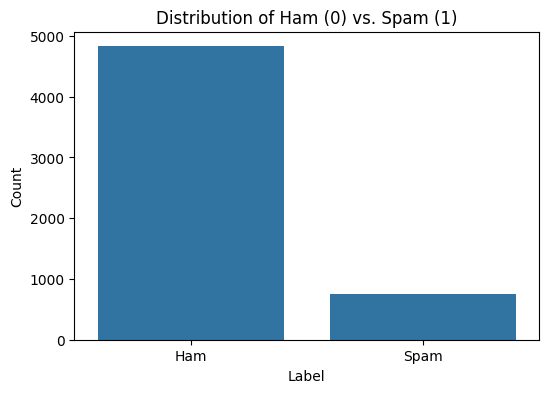

In [6]:
ham_count = df['label'].value_counts()[0]
spam_count = df['label'].value_counts()[1]

ham_to_spam_ratio = ham_count / spam_count
spam_to_ham_ratio = spam_count / ham_count

print(f'Number of Ham messages: {ham_count}')
print(f'Number of Spam messages: {spam_count}')

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham (0) vs. Spam (1)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

There are 4827 ham messages and 747 spam messages. Our two classes are quite imbalanced. We may need to account for this depending on how our model features and training look.

In [7]:
# Add a new column for message length
df['message_length'] = df['sms'].apply(len)

print('\nDataFrame with message length:')
display(df.head())


DataFrame with message length:


,sms,label,message_length
0,"Go until jurong point, crazy.. Available only ...",0,112
1,Ok lar... Joking wif u oni...\n,0,30
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,156
3,U dun say so early hor... U c already then say...,0,50
4,"Nah I don't think he goes to usf, he lives aro...",0,62


Let's see if message length shows a correlation with ham and spam classification.

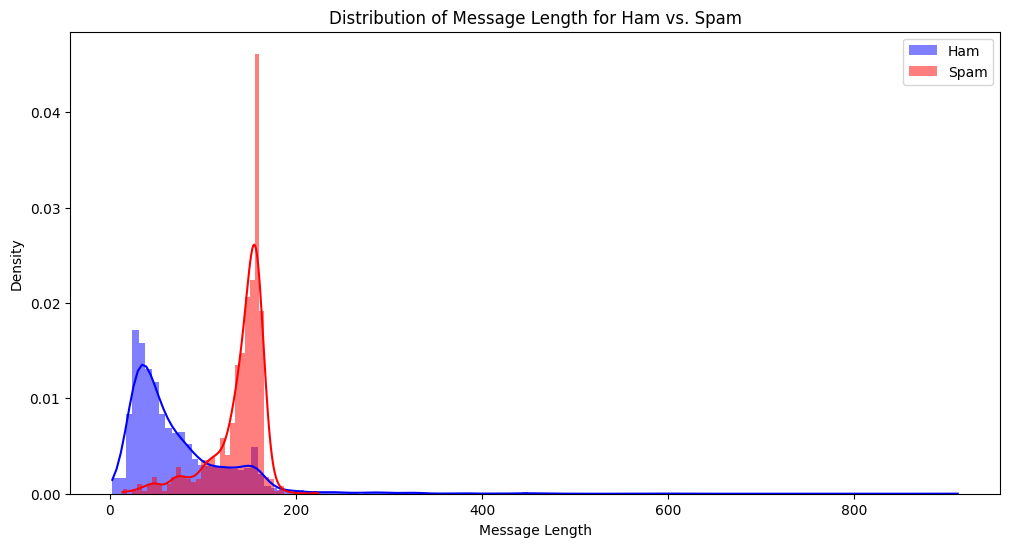

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label']==0]['message_length'], color='blue', label='Ham', kde=True, stat='density', linewidth=0)
sns.histplot(df[df['label']==1]['message_length'], color='red', label='Spam', kde=True, stat='density', linewidth=0)
plt.title('Distribution of Message Length for Ham vs. Spam')
plt.xlabel('Message Length')
plt.ylabel('Density')
plt.legend()
plt.show()

Spam messages typically are longer with more extreme spikes.

### Training/Test Split and Feature Engineering

Now that we have a sense of the full data, we'll create an 80/20 training/test data split to prepare for model creation and refining.

In [9]:
X = df['sms']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set size: {len(X_train)} samples')
print(f'Test set size: {len(X_test)} samples')
print('\nTraining set label distribution:')
print(y_train.value_counts(normalize=True))
print('\nTest set label distribution:')
print(y_test.value_counts(normalize=True))

Training set size: 4459 samples
Test set size: 1115 samples

Training set label distribution:
label
0    0.865889
1    0.134111
Name: proportion, dtype: float64

Test set label distribution:
label
0    0.866368
1    0.133632
Name: proportion, dtype: float64


Since the dataset has a very low amount of spam, we will stratify by the target variable `label` to maintain the original proportion across training and test sets to ensure we have enough spam messages in both for our process.

In [10]:
def extract_text_features(text):
    capital_letters = sum(1 for char in text if char.isupper())
    total_letters = sum(1 for char in text if char.isalpha())
    capital_ratio = capital_letters / total_letters if total_letters > 0 else 0

    uppercase_word_count = sum(1 for word in text.split() if word.isupper())

    numeric_count = sum(1 for char in text if char.isdigit())

    return pd.Series({
        'capital_ratio': capital_ratio,
        'uppercase_word_count': uppercase_word_count,
        'numeric_count': numeric_count
    })

Normally when operating on a corpus, we want to start by making all characters lowercase so that we don't end up with duplicates of the same word. When analyzing spam, there tends to be a higher amount of uppercase letters, so we want to capture that detail as well.

Generated text features for the training set:


,capital_ratio,uppercase_word_count,numeric_count
82,0.043478,0.0,0.0
1328,0.150000,1.0,11.0
577,0.024390,0.0,0.0
656,0.026316,0.0,0.0
317,0.049383,0.0,1.0


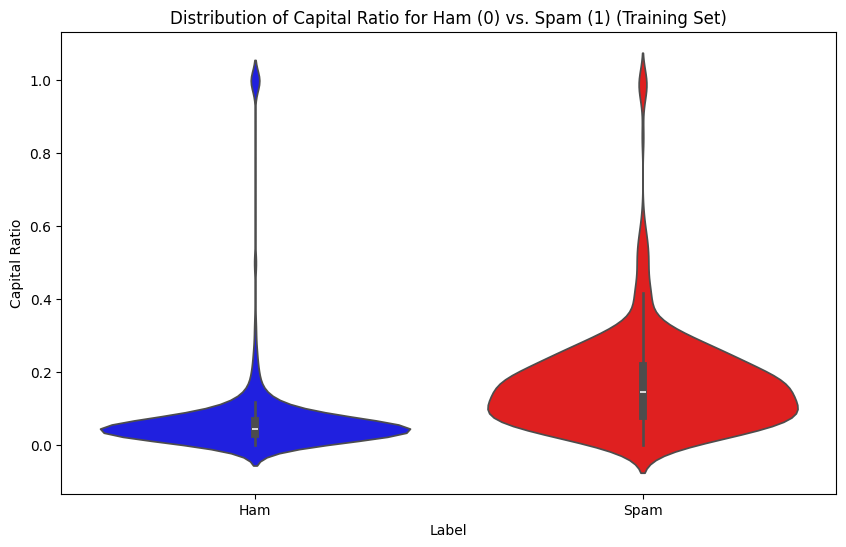

In [11]:
# Apply the feature extraction to X_train
X_train_features = X_train.apply(extract_text_features)

print('Generated text features for the training set:')
display(X_train_features.head())

X_train_eda = X_train_features.copy()
X_train_eda['label'] = y_train

plt.figure(figsize=(10, 6))
sns.violinplot(x='label', y='capital_ratio', data=X_train_eda, hue='label', palette={0: 'blue', 1: 'red'}, legend=False)
plt.title('Distribution of Capital Ratio for Ham (0) vs. Spam (1) (Training Set)')
plt.xlabel('Label')
plt.ylabel('Capital Ratio')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

We can see here that the amount of capital letters in a ham email is far less than that in spam. A ham message could be something like "I'm going to the grocery." where only the first letter is uppercase. This is closer to the way people write, especially on a phone that autocapitalizes the start of a sentence as its default behavior.

A spam message has the goal of catching a person's eye and is more likely to use all caps words like in "GREAT DEAL, DON'T MISS IT FOR THE WORLD".

In [39]:
def evaluate_classifier_performance(y_true, y_pred, title='Model Performance Evaluation', target_names=['Ham', 'Spam'], y_pred_proba=None):

    print(f'\n--- {title} ---')

    # Generate Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print('\nConfusion Matrix:')
    print(cm)

    # Generate Classification Report
    report = classification_report(y_true, y_pred, target_names=target_names)
    print('\nClassification Report:')
    print(report)

    # Determine the number of subplots needed
    num_plots = 1 if y_pred_proba is None else 2
    plt.figure(figsize=(6 * num_plots, 6)) # Adjust figure size dynamically

    # Subplot 1: Confusion Matrix
    plt.subplot(1, num_plots, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[f'Predicted {name}' for name in target_names],
                yticklabels=[f'Actual {name}' for name in target_names])
    plt.title(f'Confusion Matrix for {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Subplot 2: ROC Curve if probabilities are provided
    if y_pred_proba is not None:
        plt.subplot(1, num_plots, 2)
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC curve for {title}')
        plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

`evaluate_classifier_performance` will allow us to compare iterations of our classifier if needed. It provides a confusion matrix, a classification report, and a ROC curve. We can examine accuracy, precision, F1-score, and recall at a glance.

In [13]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Apply feature extraction to X_test as well
X_test_features = X_test.apply(extract_text_features)

# Combine TF-IDF features with extracted text features
X_train_features_array = X_train_features.values
X_test_features_array = X_test_features.values

X_train_final = hstack([X_train_tfidf, X_train_features_array])
X_test_final = hstack([X_test_tfidf, X_test_features_array])

print('\nShape of combined X_train_final:', X_train_final.shape)
print('Shape of combined X_test_final:', X_test_final.shape)

Shape of X_train_tfidf: (4459, 5000)
Shape of X_test_tfidf: (1115, 5000)

Shape of combined X_train_final: (4459, 5003)
Shape of combined X_test_final: (1115, 5003)


TF-IDF (Term Frequency-Inverse Document Frequency) analyzes the importance of a word to the corpus. It does it in 2 steps: frequency of a word in a document and frequency across documents within the entire corpus. We have multiple messages that each work as documents allowing us to use this statistic to determine which words are strong tells for spam messages.

### Model Training and Evaluation

With our features made, we will test two models, Logistic Regression and Naive Bayes. The classification we are doing is a simple binary one, so it is likely that these models will perform well with our features.

#### Logistic Regression Model Training and Evaluation


--- Logistic Regression Classifier Performance ---

Confusion Matrix:
[[959   7]
 [  8 141]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.95      0.95      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



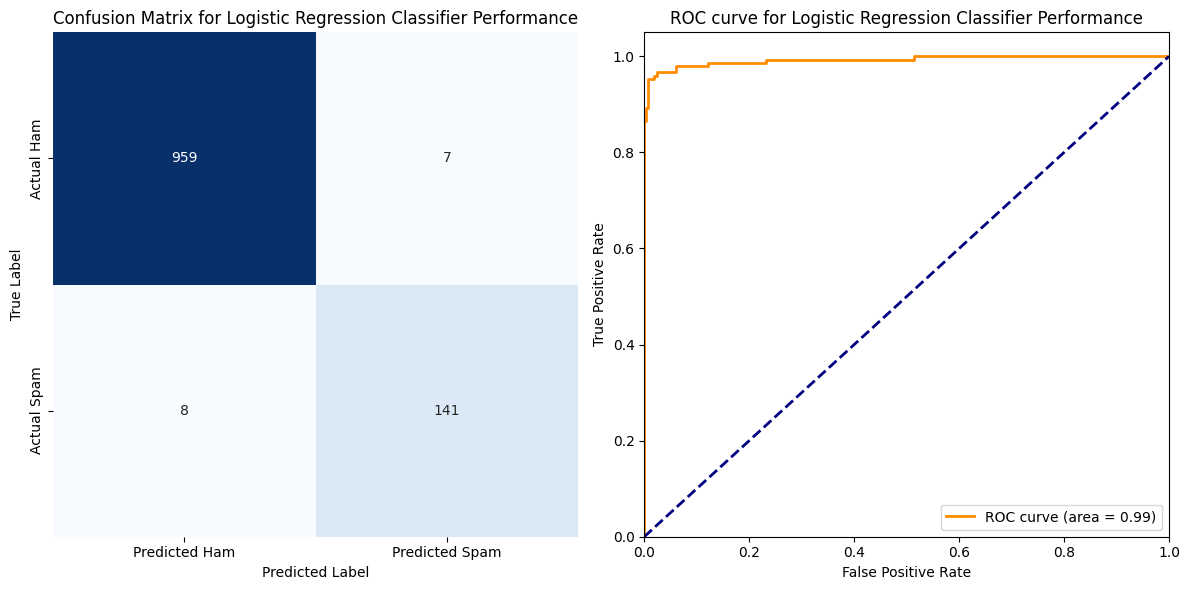

In [40]:
# Initialize and train a Logistic Regression model
logistic_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced') # 'balanced' handles class imbalance
logistic_model.fit(X_train_final, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test_final)
y_pred_proba = logistic_model.predict_proba(X_test_final)[:, 1]

# Evaluate the model
evaluate_classifier_performance(y_test, y_pred, title='Logistic Regression Classifier Performance', y_pred_proba=y_pred_proba)

The model performs extremely well. 99% accuracy is hard to beat with a total of 15 mispredicted emails. The ability for the model to detect spam was 0.95 precision and recall which was a bit less than ham, but still very strong. Likewise, the ROC curve had such a large AUC of 0.99 that it barely looks like a curve anymore.

#### Naive Bayes Model Training and Evaluation


--- Naive Bayes Classifier Performance ---

Confusion Matrix:
[[952  14]
 [ 12 137]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.91      0.92      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



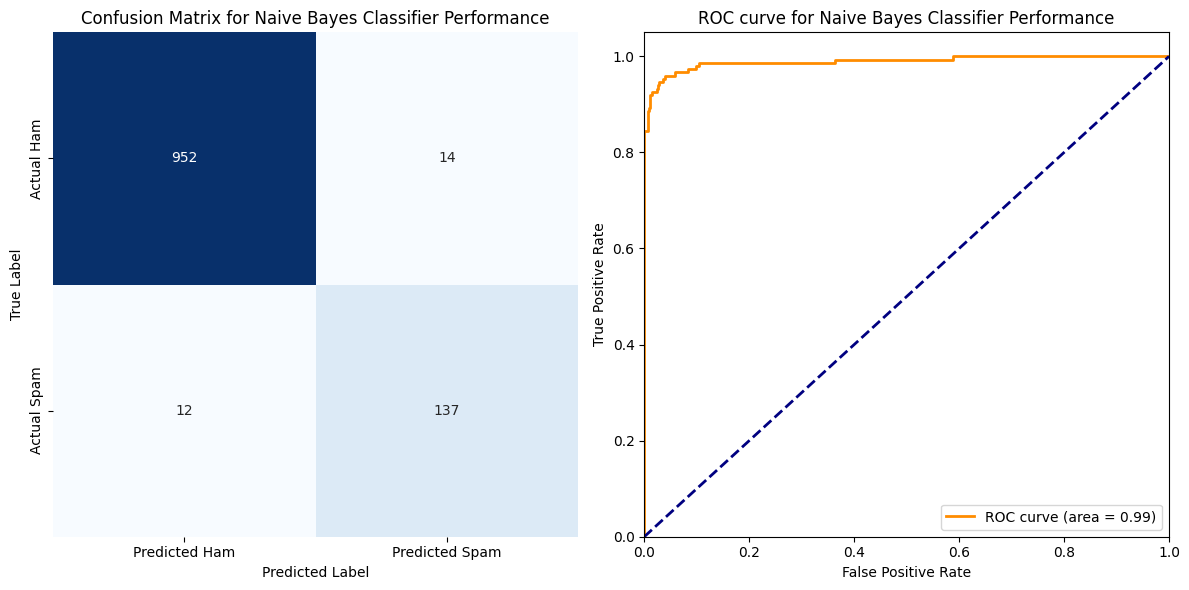

In [41]:
# Initialize and train a Naive Bayes model
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train_final, y_train)

# Make predictions on the test set using Naive Bayes
y_pred_nb = naive_bayes_model.predict(X_test_final)
y_pred_proba_nb = naive_bayes_model.predict_proba(X_test_final)[:, 1]

# Evaluate the Naive Bayes model
evaluate_classifier_performance(y_test, y_pred_nb, title='Naive Bayes Classifier Performance', y_pred_proba=y_pred_proba_nb)

This is another well performing model with a 98% accuracy and 0.99 AUC. However, the precision and recall for spam were far lower at 0.92 and 0.91 respectively. This means more false positives and false negatives, effectively just worse for everything related to determining spam.

In other scenarios, we would use the Naive Bayes model and call it a successful strong performing one because it worked on unseen data at finding the minority class a very high amount of the time.

Total number of features: 5003
First 5 feature names: ['00', '000', '008704050406', '0089', '01223585236']
Last 3 feature names (custom features): ['capital_ratio', 'uppercase_word_count', 'numeric_count']


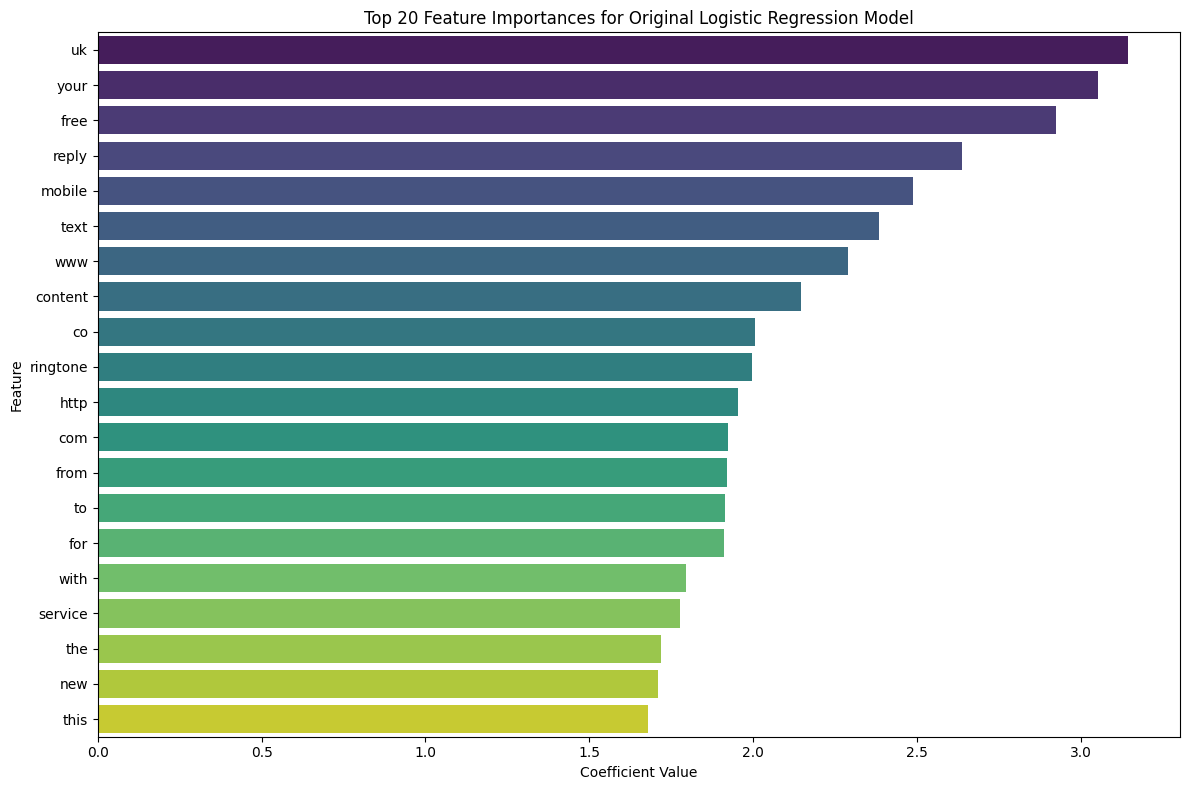

In [45]:
# Generate combined feature names for importance plotting
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
text_feature_names = X_train_features.columns.tolist()
feature_names = list(tfidf_feature_names) + text_feature_names

print(f'Total number of features: {len(feature_names)}')
print('First 5 feature names:', feature_names[:5])
print('Last 3 feature names (custom features):', feature_names[-3:])

# Extract coefficients from the original Logistic Regression model
coefficients = logistic_model.coef_[0] if len(logistic_model.coef_.shape) > 1 else logistic_model.coef_

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'feature': feature_names, 'importance': coefficients})

# Calculate absolute importance for sorting
feature_importance['abs_importance'] = feature_importance['importance'].abs()

# Sort by absolute importance and get the top 20 features
feature_importance = feature_importance.sort_values(by='abs_importance', ascending=False).head(20)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance, hue='feature', palette='viridis', legend=False)
plt.title('Top 20 Feature Importances for Original Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



These features represent the 20 most likely words to appear in spam. Some of these words such as "uk", "www", "com", and "co" seem like parts of a URL like a link that the spammers want you to click on. There are phone related words such as "mobile", "text", "ringtone", and "service". The words "free" and "new" seem like offers in a typical scam.

The words that scammers use are fairly consistent because a scam can only occur if there is something that the scammer can get from you in that email. With a clear purpose, they will be similar to each other.

### Conclusion

Some problems require more intenstive models such as ensemble methods, but the simplicity of Regular Expression showed to be sufficient and sometimes better than other options. In order to reach a highly performant Logistic Regression model we:
* Studied context agnostic metrics such as message length
* Balanced our training and test data to provide a sufficent amount of spam to detect
* Cleaned and consolidated the messages in order to analyze word frequency

Ensemble models such as random forest or hypertuning the parameters would likely improve performance, but would incur extra costs with diminishing returns.

Presentation link: